# Module: Volume (3D)

Spatial transcriptomics tissue sections are not truly 2D: they typically have a physical thickness of ~4–10 µm. Even for a relatively thin 5 µm section, 
cells can partially overlap along the z-dimension, depending on tissue orientation and how the sample is cut. As a result, methods that treat the data as purely 2D will often introduce neighborhood contamination, because transcripts from overlapping cells may be assigned to the same segmentation mask.

<center>
 <img src='../_static/img/docs/volume.png' width='90%' />
</center>

To assess how well a segmentation method resolves cell overlaps in 3D, we provide a set of metrics in the `volume` (`vl`) accessor.

In this module, we introduce metrics to quantify how strongly a method is affected by 3D overlap, and how well it can separate overlapping cells across z (e.g. quasi-3D approaches such as Proseg), or in other words, how well it can disentangle transcripts from overlapping cells.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/iGxVy8qtZnwHOju).

In [26]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load data into SegTraQ and run label transfer

In [27]:
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spatialdata as sd
import spatialdata_plot  # noqa

import segtraq

warnings.filterwarnings(action="ignore")

We load [previously built](./io.ipynb) `SpatialData` objects from 10x Genomics Xenium data segmented with Xenium's multimodal cell segmentation (`sdata_xenium`), with Proseg v2.0.5 (`sdata_proseg2`) and Proseg v3.1.0 (`sdata_proseg3`).

In [ ]:
sdata_xenium = sd.read_zarr("../../data/xenium_v1_data/sdata_xenium_crop.zarr")
sdata_proseg2 = sd.read_zarr("../../data/xenium_v1_data/sdata_proseg_v2_crop.zarr/")
sdata_proseg3 = sd.read_zarr("../../data/xenium_v1_data/sdata_proseg_v3_crop.zarr/")

Next, we initialize `SegTraQ` objects. 

In [29]:
st_xenium = segtraq.SegTraQ(
    sdata_xenium,
    tables_centroid_x_key=None,
    tables_centroid_y_key=None,
    points_background_id=-1,  # "UNASSIGNED" for Xenium prime
)

st_proseg2 = segtraq.SegTraQ(
    sdata_proseg2,
    points_cell_id_key="assignment",
    points_background_id=2**32 - 1,
    points_gene_key="gene",
    tables_area_key=None,
    tables_cell_id_key="cell",
    shapes_cell_id_key="cell",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

st_proseg3 = segtraq.SegTraQ(
    sdata_proseg3,
    points_cell_id_key="assignment",
    points_background_id=None,
    points_gene_key="gene",
    tables_area_key=None,
    tables_cell_id_key="cell",
    shapes_cell_id_key="cell",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
    filter_kwargs={"min_qv": None},
)

For easier access, we store the `SpatialData` object into a dictionary.

In [30]:
st_dict = {"xenium": st_xenium, "proseg2": st_proseg2, "proseg3": st_proseg3}

We can then transfer labels from a reference scRNA-seq dataset. 

In [31]:
adata_ref = ad.read_h5ad("../../data/BC_scRNAseq_Janesick.h5ad")

for _method, st in st_dict.items():
    st.run_label_transfer(adata_ref, ref_cell_type="celltype_major", inplace=True)

## Inspect z distribution of transcripts

We will first examine the z-distribution of transcripts in Xenium data.
Proseg includes a correction step for z-drift, which can occur when the slide is not perfectly flat—for example due to tissue cutting and mounting—or due to imaging-related effects (e.g. microscope settings or slight unevenness of the slide and imaging surface).

In [46]:
def plot_transcripts_across_z_bins(sdata, method, n_z_bins, xy_bin_size=5.0):
    df = sdata["transcripts"].compute()

    df["z_bin"] = pd.cut(df["z"], n_z_bins, labels=False)

    df["x_bin"] = (df["x"] / xy_bin_size).astype(int)
    df["y_bin"] = (df["y"] / xy_bin_size).astype(int)

    x_minb, x_maxb = df["x_bin"].min(), df["x_bin"].max()
    y_minb, y_maxb = df["y_bin"].min(), df["y_bin"].max()
    nx = x_maxb - x_minb + 1
    ny = y_maxb - y_minb + 1

    fig, axes = plt.subplots(
        1,
        n_z_bins,
        figsize=(2.2 * n_z_bins, 4),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes)

    for i in range(n_z_bins):
        ax = axes[i]

        plane = df[df["z_bin"] == i]
        counts = (
            plane.groupby(["y_bin", "x_bin"])
            .size()
            .reindex(
                pd.MultiIndex.from_product(
                    [range(y_minb, y_maxb + 1), range(x_minb, x_maxb + 1)], names=["y_bin", "x_bin"]
                ),
                fill_value=0,
            )
            .values.reshape(ny, nx)
        )

        im = ax.imshow(
            counts,
            origin="lower",
            aspect="equal",
            extent=[
                x_minb * xy_bin_size,
                (x_maxb + 1) * xy_bin_size,
                y_minb * xy_bin_size,
                (y_maxb + 1) * xy_bin_size,
            ],
        )
        ax.set_title(f"Z plane {i + 1}")
        ax.set_xlabel("x")
        if i == 0:
            ax.set_ylabel("y")

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), location="right", shrink=0.9)
    cbar.set_label(f"#transcripts per {xy_bin_size}x{xy_bin_size} bin")

    fig.suptitle(f"{method}: #transcripts per {xy_bin_size}x{xy_bin_size} bin", fontsize=14)
    plt.show()

In the raw Xenium data, we can still observe a pronounced z-drift across the tissue. In lower z-planes (e.g. Z plane 3), transcripts are more densely detected on the left side of the field of view, whereas in higher z-planes the transcript density shifts towards the right. 

Prosegs explicitly corrects for this type of depth-related variation and produces normalized z values, as can be seen [here](https://github.com/dcjones/proseg/blob/main/src/sampler/transcripts.rs#L162).

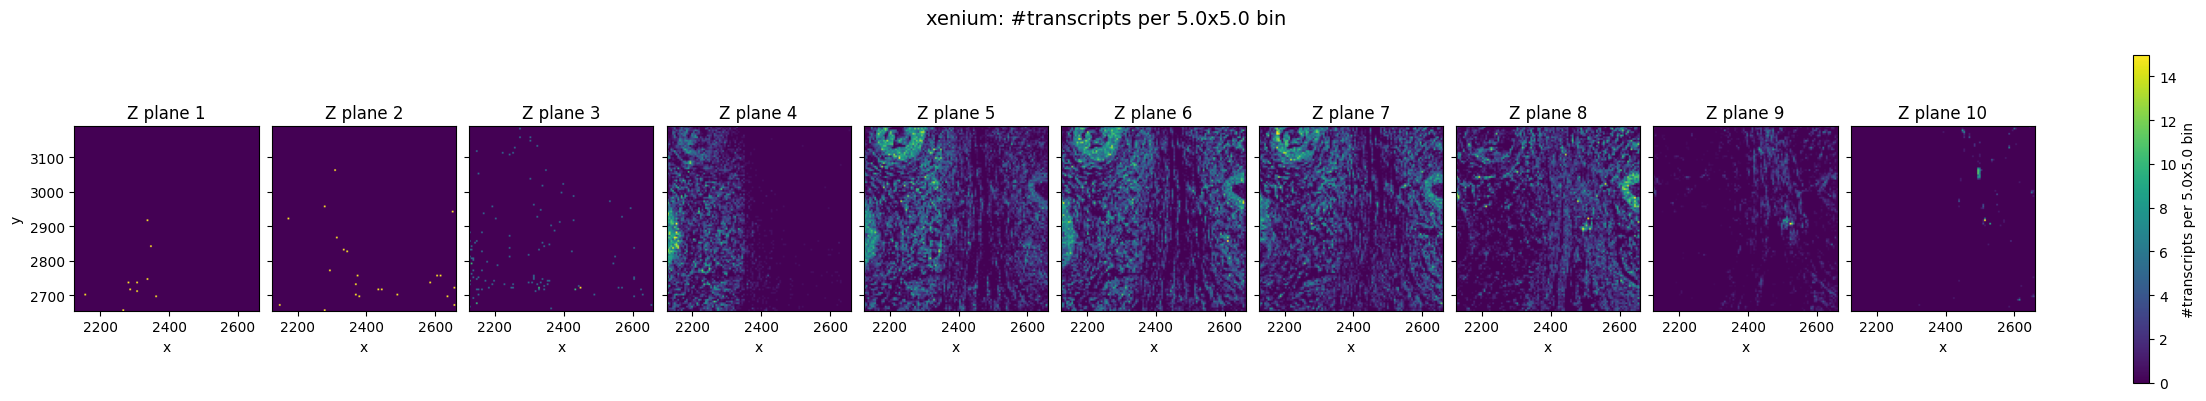

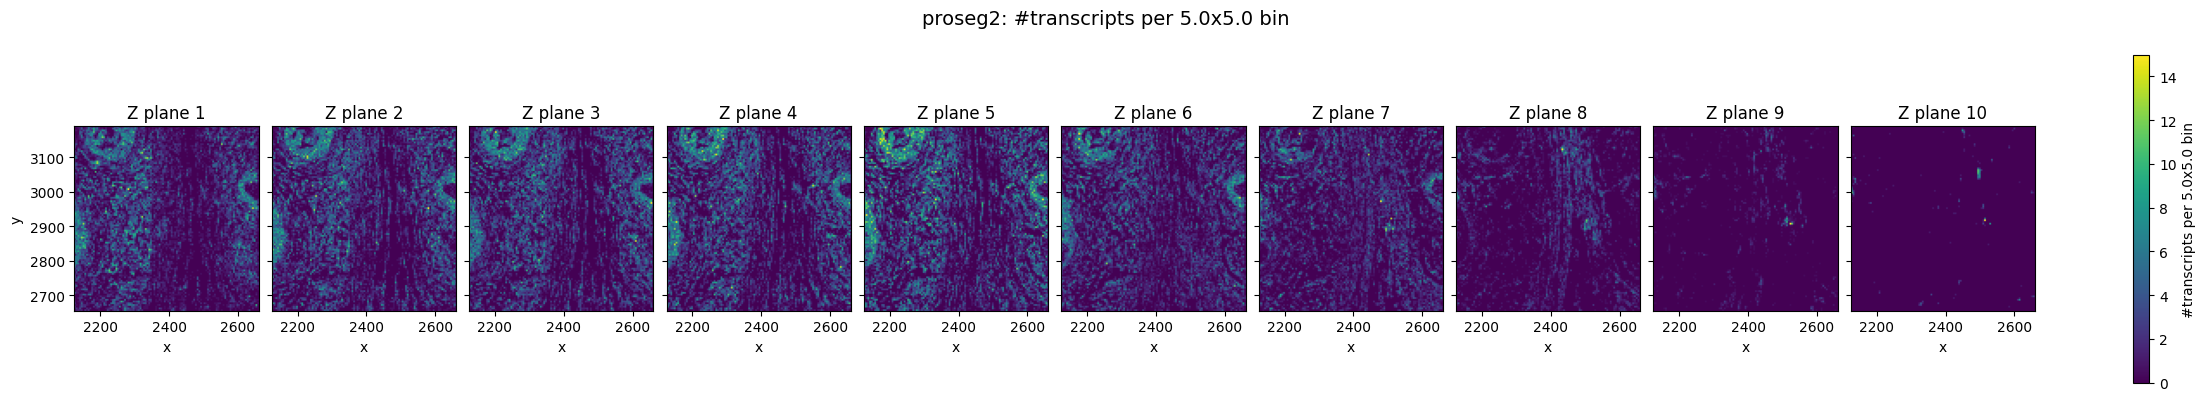

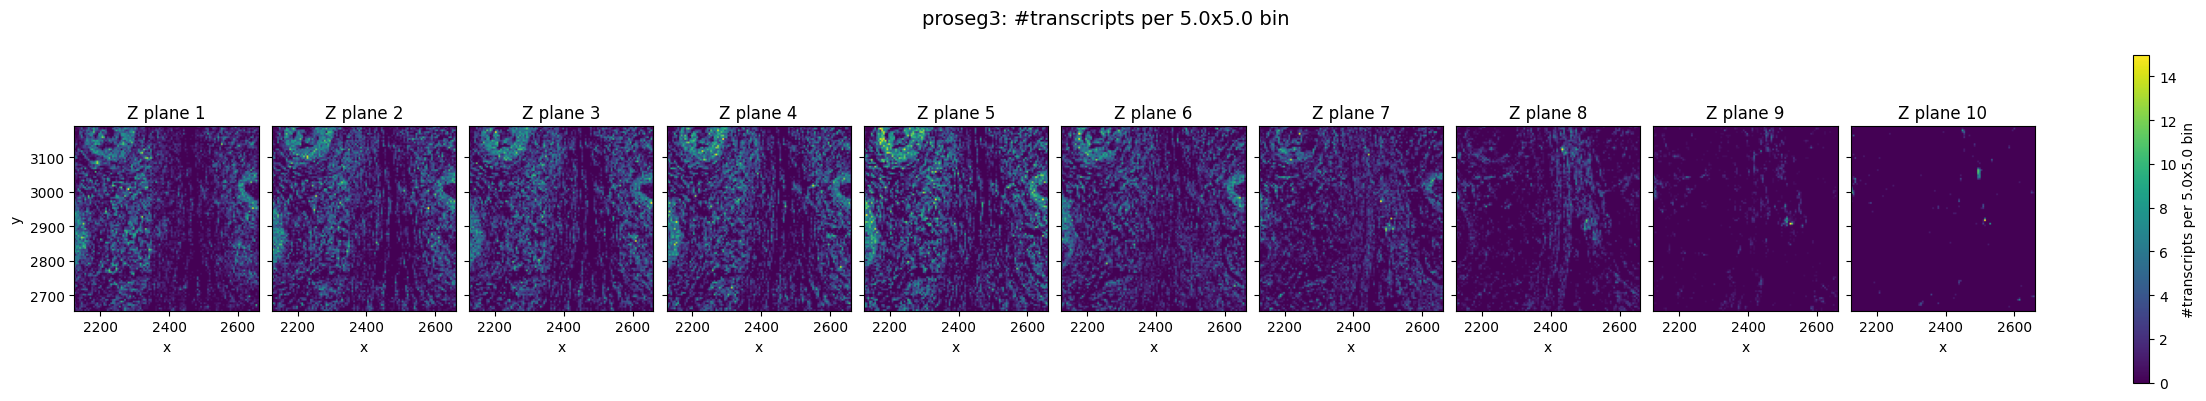

In [47]:
for method, st in st_dict.items():
    plot_transcripts_across_z_bins(st.sdata, method, 10)

## Top–bottom z consistency (cosine similarity)

To assess whether a segmented cell may contain transcripts from overlapping cells across z, we compute a top–bottom z similarity score. The intuition is that a correctly segmented single cell should have a broadly consistent expression profile across depth, while merged/overlapping cells may show depth-dependent expression shifts, lowering similarity.

For each cell, we split its transcripts into:

bottom: z ≤ q (default  q=0.30)
top: z ≥ 1−q

We aggregate gene counts for both parts, normalize within each cell using the combined library size (top+bottom), apply `log1p`, and compute the cosine similarity between the two vectors (considering genes non-zero in either part). To enable fair comparisons between methods, we optionally correct for global z-drift by normalizing z coordinates before splitting transcripts into top and bottom (default `correct_z_drift=True`); Proseg already performs this normalization internally. Cells are set to `NaN` if either part has fewer than `min_transcripts` transcripts (default 10) or fewer than `min_genes` genes (default 5).

In [48]:
for method, st in st_dict.items():
    if method.startswith("p"):
        _cos_sim = st.vl.similarity_top_bottom(
            correct_z_drift=False
        )  # correct for z drift already done internally in proseg
    else:
        _cos_sim = st.vl.similarity_top_bottom()

In [49]:
def density_plot_feature(sdata_dict, feature, figsize=(5, 3)):
    all_feats = []
    for method, st in sdata_dict.items():
        feat = st.sdata["table"].obs[feature].to_frame(feature)
        feat["method"] = method
        all_feats.append(feat)

    df = pd.concat(all_feats, ignore_index=True)
    df["method"] = df["method"].astype(str)

    plt.figure(figsize=figsize)
    sns.kdeplot(data=df, x=feature, hue="method", common_norm=False, palette="Set2", fill=False)
    plt.tight_layout()

Proseg version 2 and 3 show the best correlation between top and bottom z-plane overall.

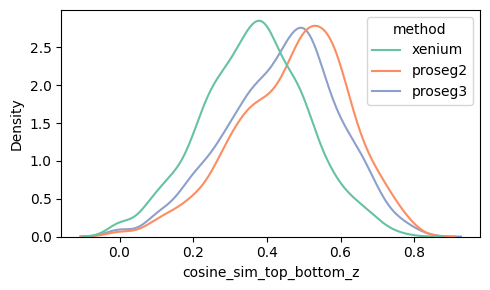

In [50]:
density_plot_feature(st_dict, "cosine_sim_top_bottom_z")

Even after within-cell normalization, high-count cells have less sampling noise, so their top and bottom gene profiles are estimated more reliably and tend to look more similar, which increases cosine similarity. In low-count cells, random dropout and sparse gene sampling make the two vectors noisier and artificially reduce the similarity. 

In addition, high-count cells are often larger in size and therefore span a larger proportion of z, which might reduce the risk of 3D overlap and hence lead to increase similarity between top and bottom plane (`cosine_sim_top_bottom_z`).

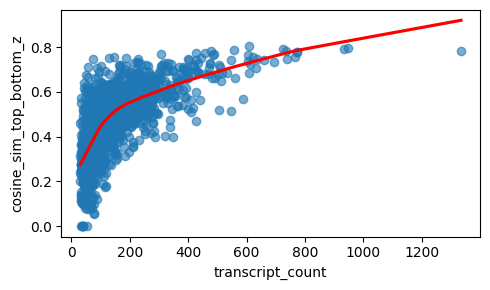

In [51]:
df = st_dict["proseg2"].sdata.tables["table"].obs[["cosine_sim_top_bottom_z", "transcript_count"]].dropna()

plt.figure(figsize=(5, 3))
sns.regplot(
    data=df,
    x="transcript_count",
    y="cosine_sim_top_bottom_z",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"},
    lowess=True,  # nonlinear
    ci=95,
)
plt.tight_layout()

The relationship between `cosine_sim_top_bottom_z` and `transcript_count` looks linear. The analytical Pearson residuals lead to stabilisation of the count effect on the cosine similarity.

In [52]:
from sklearn.metrics import r2_score

x = df["transcript_count"].to_numpy()
y = df["cosine_sim_top_bottom_z"].to_numpy()

# Linear fit
coef_lin = np.polyfit(x, y, deg=1)
y_hat_lin = np.polyval(coef_lin, x)
r2_lin = r2_score(y, y_hat_lin)

# Log fit
x_log = np.log1p(x)
coef_log = np.polyfit(x_log, y, deg=1)
y_hat_log = np.polyval(coef_log, x_log)
r2_log = r2_score(y, y_hat_log)

# sqrt fit
x_sqrt = np.sqrt(x)
coef_sqrt = np.polyfit(x_sqrt, y, deg=1)
y_hat_sqrt = np.polyval(coef_sqrt, x_sqrt)
r2_sqrt = r2_score(y, y_hat_sqrt)

print(f"R² linear: {r2_lin:.3f}")
print(f"R² log1p:  {r2_log:.3f}")
print(f"R² sqrt:   {r2_sqrt:.3f}")

R² linear: 0.386
R² log1p:  0.500
R² sqrt:   0.465


Thus, it makes sense to plot the expression similarity between top and bottom plane per cell type, as this have less variation in transcript counts and cell size. 

This confirms that Proseg 2 and 3 show the highest expression similarity between top and bottom plane for each cell type.

In [53]:
def boxplot_per_celltype(st_dict, feature, q=1):
    dfs = []
    for method, st in st_dict.items():
        obs = st.sdata["table"].obs[st.sdata["table"].obs["transferred_cell_type"].notna()].copy()
        obs["transferred_cell_type"] = obs["transferred_cell_type"].cat.remove_unused_categories()
        tmp = obs[["transferred_cell_type", feature]].copy()
        tmp["method"] = method
        dfs.append(tmp)

    df = pd.concat(dfs, ignore_index=True)
    df = df[(df[feature] <= df[feature].quantile(q))]

    fig, ax = plt.subplots(figsize=(15, 5))

    sns.boxplot(
        data=df,
        x="transferred_cell_type",
        y=feature,
        hue="method",
        showcaps=True,
        showfliers=False,
        palette="Set2",
        ax=ax,
    )

    fig.tight_layout()
    plt.show()

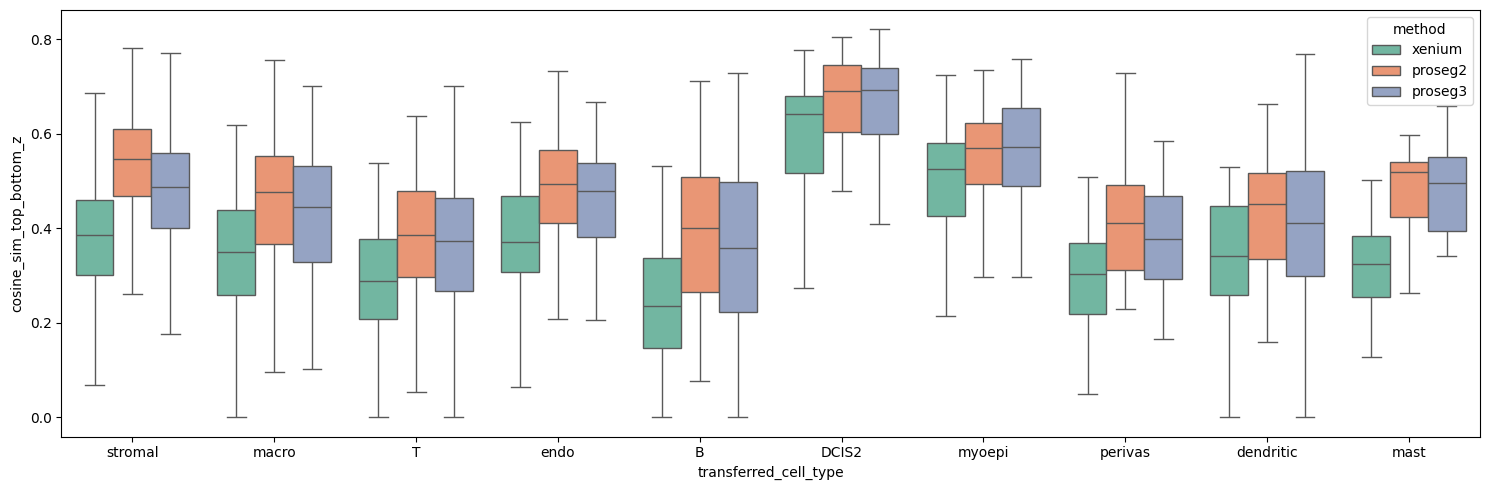

In [54]:
boxplot_per_celltype(st_dict, "cosine_sim_top_bottom_z")

Proseg achieves this despite having a lower mean transcript count overall, which would typically reduce the expected correlation.

In [55]:
for method, st in st_dict.items():
    print(f"{method} mean transcript count: {st.sdata.tables['table'].obs['transcript_count'].mean()}")

xenium mean transcript count: 150.79718490083172
proseg2 mean transcript count: 140.00259067357513
proseg3 mean transcript count: 119.69210697977822


## Heterotypic overlap area/fraction (detecting 3D overlaps)

This metric is designed to quantify where a quasi-3D method detects overlaps across z. It can only be computed for methods that output per-z-layer cell polygons (e.g. Proseg), because it explicitly compares cell boundaries between different z layers.

Because each cell has can have polygons across more than one z layer (`cell_boundaries_z0`, …), we first pick a single representative polygon per cell: the polygon with the largest area across z. We then compare this representative polygon to polygons from other z layers, excluding polygons from the same cell and restricting to different cell types (based on `transferred_cell_type`). Cells for which no label could be assigned (`transferred_cell_type` is NaN) can either be treated as a separate category (default: `treat_as_label`) or excluded from the analysis.

For each cell we report:

`heterotypic_overlap_area`: total area where the representative polygon overlaps with polygons of other cell types in different z layers

`heterotypic_overlap_fraction`: the same overlap area normalized by the cell’s polygon area

This metric is not intended as a standalone quality score, but is most informative when interpreted alongside other measures (see next chapter).

In [56]:
proseg_dict = st_dict.copy()
proseg_dict.pop("xenium", None)

In [59]:
for _method, st in proseg_dict.items():
    if "proseg" in method:
        shapes_key_list = ["cell_boundaries_z0", "cell_boundaries_z1", "cell_boundaries_z2", "cell_boundaries_z3"]
        st.vl.fraction_heterotypic_overlap(unknown_policy="exclude", shapes_key_list=shapes_key_list)

Below we can see the distribution of the `heterotypic_overlap_area` and `heterotypic_overlap_fraction` in proseg v2 and v3. Some cells have heterotypic overlap fractions > 50%. 

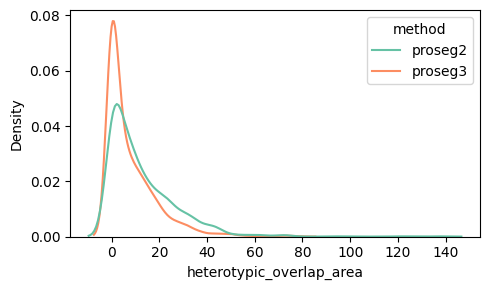

In [60]:
density_plot_feature(proseg_dict, "heterotypic_overlap_area")

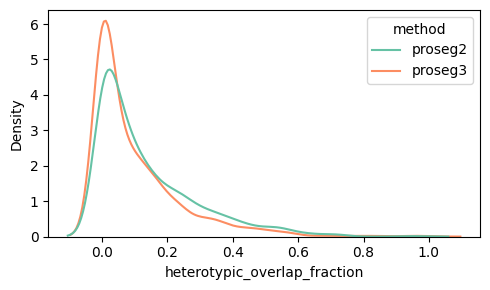

In [61]:
density_plot_feature(proseg_dict, "heterotypic_overlap_fraction")

Spatially, it is often more informative to visualize cells with high `heterotypic_overlap_area` rather than high heterotypic_overlap_fraction. The fraction normalizes by cell size, so very small cells (often partial cells near the top or bottom z-planes due to tissue cutting) can show high values (often close to 1) even when the absolute overlap is negligible. In contrast, the overlap area highlights regions where a substantial amount of tissue is involved in cross-type overlap.

Let's have a look at a cell with a high `heterotypic_overlap_area` in proseg2. It is a stromal cell that overlaps a dendritic cell (black cross marks cell centroid).

WARNING  Found 16 NaN values in color data. These observations will be colored with the 'na_color'.                


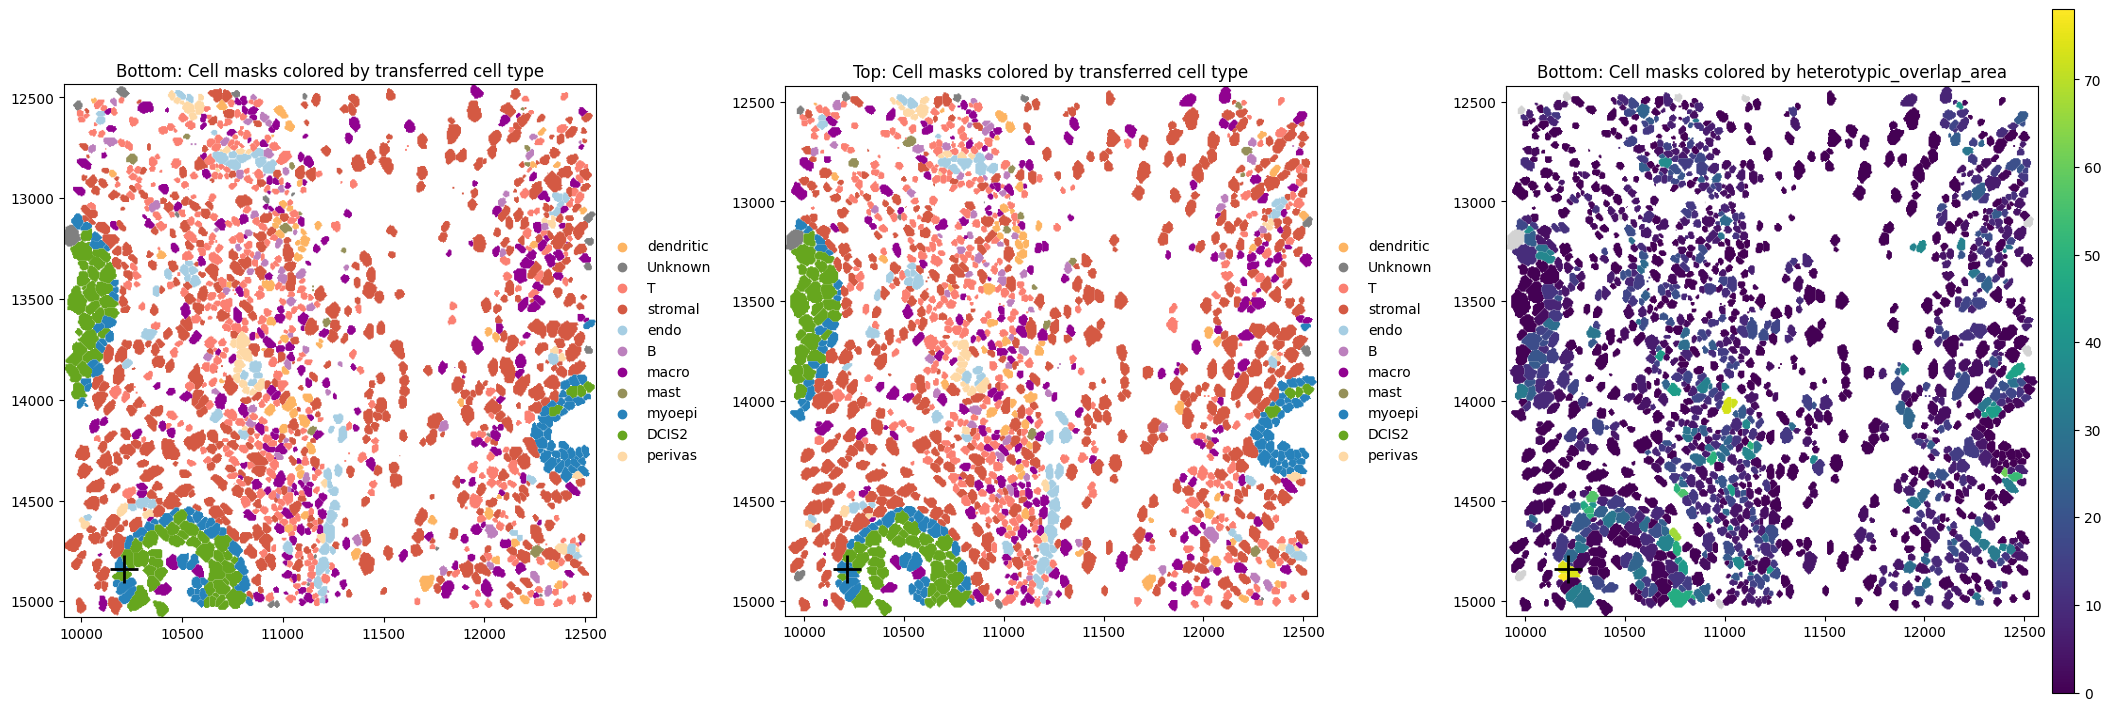

In [62]:
# Identify cell with high heterotypic_overlap_area
tbl = st_proseg3.sdata.tables["table"]
rank = 2
idx = tbl.obs["heterotypic_overlap_area"].nlargest(rank).index[rank - 1]
x0, y0 = tbl.obs.loc[idx, "centroid_x"] / 0.2125, tbl.obs.loc[idx, "centroid_y"] / 0.2125

# Define color palette for plotting
col_celltype = {
    "T": "#fb8072",
    "B": "#bc80bd",
    "macro": "#910290",
    "dendritic": "#fdb462",
    "mast": "#959059",
    "perivas": "#fed9a6",
    "endo": "#a6cee3",
    "myoepi": "#2782bb",
    "DCIS1": "#3c7761",
    "DCIS2": "#66a61e",
    "tumor": "#66c2a5",
    "stromal": "#d45943",
    "Unknown": "#808080",
}

axes = plt.subplots(1, 3, figsize=(21, 7), constrained_layout=True)[1].flatten()

s = st_proseg3.sdata.tables["table"].obs["transferred_cell_type"]
if pd.api.types.is_categorical_dtype(s):
    s = s.cat.add_categories(["Unknown"])

st_proseg3.sdata.tables["table"].obs["transferred_celltype_plot"] = s.fillna("Unknown")

labels = st_proseg3.sdata.tables["table"].obs["transferred_celltype_plot"].unique().astype(str).tolist()
cols = [col_celltype[lab] for lab in labels]

# Bottom plane
st_proseg3.sdata.tables["table"].obs["region"] = "cell_boundaries_z0"
st_proseg3.sdata.set_table_annotates_spatialelement("table", region="cell_boundaries_z0")

st_proseg3.sdata.pl.render_shapes(
    "cell_boundaries_z0", color="transferred_celltype_plot", palette=cols, groups=labels
).pl.show(ax=axes[0], title="Bottom: Cell masks colored by transferred cell type", coordinate_systems="global")

# Top plane
st_proseg3.sdata.tables["table"].obs["region"] = "cell_boundaries_z1"
st_proseg3.sdata.set_table_annotates_spatialelement("table", region="cell_boundaries_z1")

st_proseg3.sdata.pl.render_shapes(
    "cell_boundaries_z1", color="transferred_celltype_plot", palette=cols, groups=labels
).pl.show(ax=axes[1], title="Top: Cell masks colored by transferred cell type", coordinate_systems="global")

st_proseg3.sdata.pl.render_shapes("cell_boundaries_z1", color="heterotypic_overlap_area").pl.show(
    ax=axes[2], title="Bottom: Cell masks colored by heterotypic_overlap_area", coordinate_systems="global"
)

# Add landmark at centroid of cell with high heterotypic overlap area
for ax in axes:
    ax.scatter([x0], [y0], marker="+", s=400, c="black", linewidths=2, zorder=10)

## Mean VSI per cell (ovrlpy-based vertical signal integrity)
[Ovrlpy](https://www.biorxiv.org/content/10.1101/2025.01.13.632601v2.full) is a package for detecting 3D overlap in spatial transcriptomics by using transcript coordinates.
It computes a Vertical Signal Integrity (VSI) map that highlights regions where the transcriptome signal is consistent across depth versus regions that likely contain vertical mixing (e.g. overlapping cells or tissue folds). Conceptually, VSI compares local gene expression between a virtual top and virtual bottom subslice of the tissue: high VSI indicates strong agreement, while low VSI suggests potential 3D overlap or other depth-related artifacts. 

To connect this pixel-level map to our 3D metrics, we compute mean VSI per cell by sampling the VSI value at each transcript’s (x,y) position and averaging these values across all transcripts assigned to the same cell.  

We can run the compute the VSI map and extract the mean VSI per cell.

In [63]:
n_celltypes = st_xenium.sdata.tables["table"].obs["transferred_cell_type"].nunique()

for _method, st in st_dict.items():
    _mean_vsi = st.vl.vertical_signal_integrity_per_cell(ovrlpy_init_kwargs={"n_components": n_celltypes}, n_workers=8)

Running vertical adjustment
Creating gene expression embeddings for visualization
determining pseudocells
found 371 pseudocells
sampling expression:


100%|██████████| 1/1 [00:00<00:00,  5.79it/s]


Modeling 10 pseudo-celltype clusters;
Creating signal integrity map


100%|██████████| 4/4 [00:01<00:00,  3.06it/s]


Running vertical adjustment
Creating gene expression embeddings for visualization
determining pseudocells
found 378 pseudocells
sampling expression:


...

Running vertical adjustment
Creating gene expression embeddings for visualization
determining pseudocells
found 364 pseudocells
sampling expression:


100%|██████████| 1/1 [00:00<00:00,  7.68it/s]

Modeling 10 pseudo-celltype clusters;


Creating signal integrity map


100%|██████████| 4/4 [00:01<00:00,  2.98it/s]


Plotting `cosine_sim_top_bottom_z` against `mean_vsi` shows a weaker association in Proseg v2 (and Proseg v3) than in Xenium. One plausible explanation is that Proseg’s quasi-3D assignment reduces the impact of vertically mixed regions on per-cell expression consistency: even where `mean_vsi` is low (regions that look vertically inconsistent in the raw transcript field), Proseg can assign transcripts more coherently to individual cells, resulting in relatively high `cosine_sim_top_bottom_z`. In Xenium, by contrast, low-VSI regions more directly translate into lower within-cell top–bottom similarity, yielding a stronger correlation.

We filter out cells with transcript counts below the 10th percentile, as low-count cells tend to produce noisier and less stable similarity estimates.

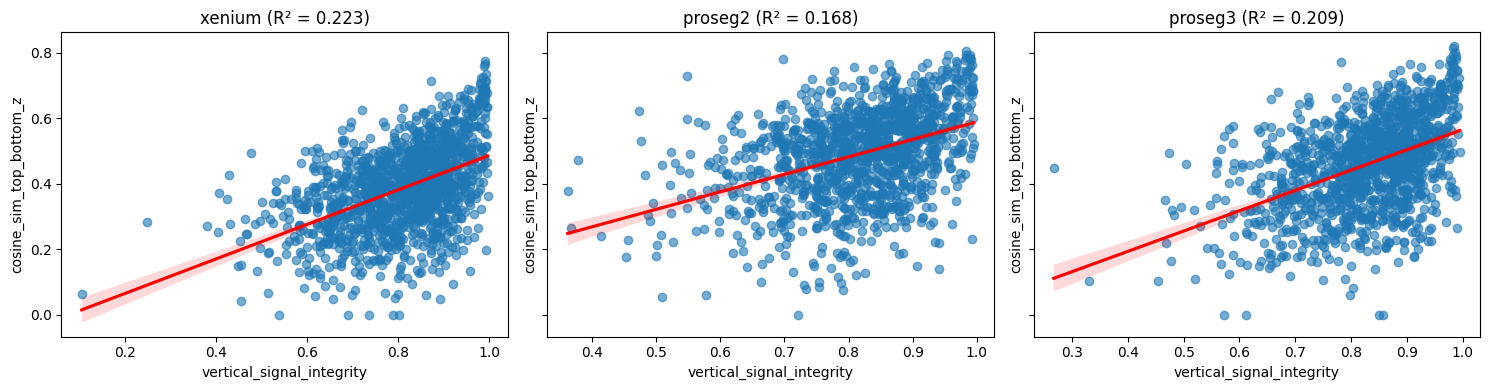

In [64]:
n = len(st_dict)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)
axes = np.atleast_1d(axes)

for ax, (method, st) in zip(axes, st_dict.items(), strict=False):
    df = (
        st.sdata.tables["table"]
        .obs[["vertical_signal_integrity", "cosine_sim_top_bottom_z", "transcript_count"]]
        .dropna()
    )
    df = df[df["transcript_count"] > df["transcript_count"].quantile(0.1)]  # filter low count cells

    r = np.corrcoef(df["vertical_signal_integrity"], df["cosine_sim_top_bottom_z"])[0, 1]
    r2 = r**2

    sns.regplot(
        data=df,
        x="vertical_signal_integrity",
        y="cosine_sim_top_bottom_z",
        scatter_kws={"alpha": 0.6},
        line_kws={"color": "red"},
        # lowess=True,
        ci=95,
        ax=ax,
    )

    ax.set_title(f"{method} (R² = {r2:.3f})")
    ax.set_xlabel("vertical_signal_integrity")
    ax.set_ylabel("cosine_sim_top_bottom_z")

fig.tight_layout()
plt.show()

In addition, proseg v2 and v3 shows large `heterotypic_overlap_fraction` values at low `mean_vsi`, this supports the idea that Proseg is successfully detecting substantial cross-type overlap in regions with poor vertical signal integrity. In other words, low-VSI regions (where the raw transcript field appears vertically inconsistent and prone to 3D mixing) coincide with locations where Proseg identifies strong heterotypic overlap across z-layers. This suggests that the overlap signal captured by ovrlpy (low VSI) corresponds to biologically and geometrically meaningful overlap events that Proseg can partially represent in its quasi-3D segmentation output.

We evaluate this relation in cell types individually to reduce confounding from large cell-type–specific differences in transcript abundance.

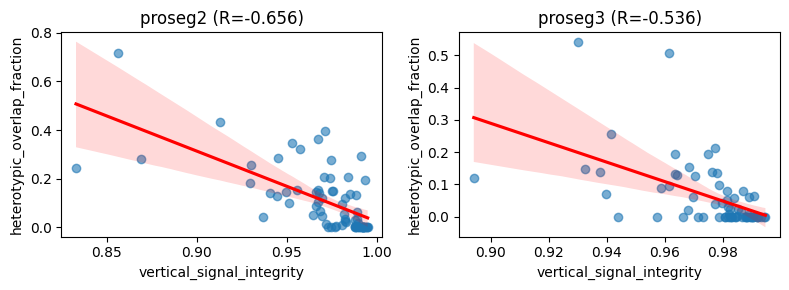

In [65]:
n = len(proseg_dict)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 3), sharex=False, sharey=False)
axes = np.atleast_1d(axes)

for j, (method, st) in enumerate(proseg_dict.items()):
    obs = st.sdata.tables["table"].obs

    df = obs.loc[
        obs["transferred_cell_type"] == "DCIS2", ["vertical_signal_integrity", "heterotypic_overlap_fraction"]
    ].dropna()

    ax = axes[j]
    r = np.corrcoef(df["vertical_signal_integrity"], df["heterotypic_overlap_fraction"])[0, 1]

    sns.regplot(
        data=df,
        x="vertical_signal_integrity",
        y="heterotypic_overlap_fraction",
        scatter_kws={"alpha": 0.6},
        line_kws={"color": "red"},
        ci=95,
        ax=ax,
    )

    ax.set_title(f"{method} (R={r:.3f})")
    ax.set_xlabel("vertical_signal_integrity")
    ax.set_ylabel("heterotypic_overlap_fraction")

fig.tight_layout()
plt.show()

Wrapper to run all metrics (including label transfer).

In [ ]:
for method, st in st_dict.items():
    if "proseg" in method:
        shapes_key_list = ["cell_boundaries_z0", "cell_boundaries_z1", "cell_boundaries_z2", "cell_boundaries_z3"]

        st.run_volume(
            adata_ref=adata_ref,
            ref_cell_type="celltype_major",
            heterotypic_overlap_kwargs={"shapes_key_list": shapes_key_list},
        )

    else:
        st.run_volume(adata_ref=adata_ref, ref_cell_type="celltype_major")

## Session Info

In [28]:
print(sd.__version__)  # spatialdata
print(spatialdata_plot.__version__)

0.7.2
0.3.4
